In [ ]:
!pip install kagglehub

Dataset Download

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("briscdataset/brisc2025")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brisc2025' dataset.
Path to dataset files: /kaggle/input/brisc2025


In [ ]:
!mv /kaggle/input/brisc2025/brisc2025/classification_task /content/dataset

Streaming output truncated to the last 5000 lines.
mv: cannot remove '/kaggle/input/brisc2025/brisc2025/classification_task/train/pituitary/brisc2025_train_04966_pi_sa_t1.jpg': Read-only file system
mv: cannot remove '/kaggle/input/brisc2025/brisc2025/classification_task/train/pituitary/brisc2025_train_03927_pi_ax_t1.jpg': Read-only file system
mv: cannot remove '/kaggle/input/brisc2025/brisc2025/classification_task/train/pituitary/brisc2025_train_03781_pi_ax_t1.jpg': Read-only file system
mv: cannot remove '/kaggle/input/brisc2025/brisc2025/classification_task/train/pituitary/brisc2025_train_04275_pi_co_t1.jpg': Read-only file system
mv: cannot remove '/kaggle/input/brisc2025/brisc2025/classification_task/train/pituitary/brisc2025_train_04469_pi_co_t1.jpg': Read-only file system
mv: cannot remove '/kaggle/input/brisc2025/brisc2025/classification_task/train/pituitary/brisc2025_train_04872_pi_sa_t1.jpg': Read-only file system
mv: cannot remove '/kaggle/input/brisc2025/brisc2025/classifi

Data Inspection

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.6 MB/s eta 0:00:00


Imports

In [ ]:
import os
import math
import time
import random
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

# torch core
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torch.amp import autocast, GradScaler

# torchvision
import torchvision.transforms as transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights

# PyG
from torch_geometric.nn import SAGEConv, global_mean_pool
from torch_geometric.data import Data, Batch

# sklearn
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# plotting
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

In [ ]:
from torch_geometric.nn import SAGEConv, global_mean_pool, global_max_pool

Device Setup

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Device ─Device───────────────────────────────────
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_DTYPE  = torch.float16          # T4 → float16
USE_SCALER = True                   # float16 needs GradScaler

print(f"Device  : {DEVICE}")
print(f"GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"AMP     : {AMP_DTYPE}")

Device  : cuda
GPU     : Tesla T4
AMP     : torch.float16


Paths

In [ ]:
# ── Paths ─────────────────────────────────────
DATA_ROOT   = Path('/content/dataset')
TRAIN_DIR   = DATA_ROOT / 'train'
TEST_DIR    = DATA_ROOT / 'test'
CACHE_DIR   = Path('/content/feature_cache')      # frozen ViT feature cache
DRIVE_DIR   = Path('/content/drive/MyDrive/vit_sage')
CACHE_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_DIR.mkdir(parents=True, exist_ok=True)


Configurations and hyperparameters

In [ ]:
def get_temperature(epoch, total_epochs, temp_start=1.0, temp_end=0.5):
    """
    Slower Linear Decay with a higher floor.
    Ensures gradients stay alive throughout the 15-20 epochs.
    """
    # 1. Warmup: Keep it soft for the first 3 epochs so SAGE sees variety
    if epoch < 3:
        return temp_start

    # 2. Slow Linear Decay
    # We don't want to go to 0.1. A floor of 0.4 or 0.5 is much safer
    # for 15-epoch training on T4.
    total_decay_steps = total_epochs - 3
    current_step = epoch - 3

    decay = current_step / max(total_decay_steps, 1)
    temp = temp_start - (temp_start - temp_end) * decay

    return max(temp, temp_end)

In [ ]:
CONFIG = {
    # -- data --
    'image_size': 224,
    'num_classes': 4,
    'classes': ['glioma', 'meningioma', 'no_tumor', 'pituitary'],

    # -- ViT backbone --
    'vit_hidden_dim': 768,
    'num_patches': 196,
    'freeze_blocks': 8,           # Blocks 0-7 frozen, 8-11 trainable

    # -- Token Selector --
    'num_tokens_K': 31,           # 🚀 REVERTED: 31 is more precise for tumor "structural" focus
    'num_tokens_total': 32,       # 31 patches + 1 CLS
    'token_temp_start': 1.0,
    'token_temp_end': 0.5,

    # -- MLP projector --
    'proj_input': 768,
    'proj_hidden': 512,           # Increased capacity for non-linear mapping
    'proj_output': 384,           # Increased fidelity
    'dropout_proj': 0.2,
    # -- SAGE --
    'sage_hidden': 384,           # Matches proj_output
    'sage_layers': 4,
    'sage_dropout': 0.3,      # 🚀 FIXED: 2 was too shallow for 98% accuracy

    # -- Early Stopping --
    'es_patience': 5,            # 🚀 ADD THIS: Needed for Cell 10's EarlyStopping
    'es_min_delta': 1e-4,        # 🚀 ADD THIS: Needed for Cell 10's EarlyStopping

    # -- graph --
    'graph_type': 'grid',         # Must use 8-connectivity + bidirectional CLS in Cell 6

    # -- auxiliary losses --
    'lambda_entropy': 0.02,       # 🚀 INCREASED: Force sharper selection
    'lambda_diversity': 0.01,      # 🚀 RESTORED: Prevents "node collapse" where it picks the same spot

    # -- training --
    'epochs': 20,                 # 🚀 INCREASED: Graph reasoning takes longer to converge than CNNs
    'batch_size': 64,             # Perfect for T4 (16GB)
    'lr': 1e-4,
    'weight_decay': 0.05,         # 🚀 INCREASED: Prevents overfitting on the small dataset
    'n_folds': 5,

    # -- scheduler --
    'scheduler': 'cosine',
    'amp_dtype': AMP_DTYPE,
    'use_scaler': USE_SCALER,
    'dropout_head': 0.4,          # Added to prevent final MLP overfitting
}

Dataset class

In [ ]:
from PIL import Image # 🔥 Fix 1: Import at top level

class BrainTumorDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = torch.tensor(labels, dtype=torch.long) # 🔥 Pre-convert to tensor
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Using a try-except block is safer for large kaggle datasets
        try:
            img = Image.open(self.image_paths[idx]).convert('RGB')
            if self.transform:
                img = self.transform(img)
            return img, self.labels[idx]
        except Exception as e:
            print(f"Error loading {self.image_paths[idx]}: {e}")
            # Return a blank image or handle as needed
            return torch.zeros((3, 224, 224)), self.labels[idx]

Dataset Transforms

In [ ]:

def get_transforms(image_size=224):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

In [ ]:
def load_dataset_paths(root_dir):
    root_dir     = Path(root_dir)
    classes      = sorted([d.name for d in root_dir.iterdir()
                           if d.is_dir()])
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
    image_paths, labels = [], []
    exts = {'.jpg', '.jpeg', '.png'}

    for cls in classes:
        cls_dir = root_dir / cls
        for fpath in sorted(cls_dir.iterdir()):
            if fpath.suffix.lower() in exts:
                image_paths.append(fpath)
                labels.append(class_to_idx[cls])

    print(f"  Loaded  : {root_dir.name} — {len(image_paths)} images")
    print(f"  Classes : {class_to_idx}")
    return image_paths, labels, class_to_idx


# ── Load paths ────────────────────────────────
print("Loading dataset paths...")
train_paths, train_labels, class_to_idx = load_dataset_paths(TRAIN_DIR)
test_paths,  test_labels,  _            = load_dataset_paths(TEST_DIR)

train_labels_np = np.array(train_labels)
test_labels_np  = np.array(test_labels)

idx_to_class = {v: k for k, v in class_to_idx.items()}

print(f"\nTrain label distribution:")
for cls, idx in class_to_idx.items():
    count = (train_labels_np == idx).sum()
    print(f"  {cls:<15} → {count} images (label {idx})")

print(f"\nTest label distribution:")
for cls, idx in class_to_idx.items():
    count = (test_labels_np == idx).sum()
    print(f"  {cls:<15} → {count} images (label {idx})")

print(f"\nidx_to_class : {idx_to_class}")

Loading dataset paths...
  Loaded  : train — 5000 images
  Classes : {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}
  Loaded  : test — 1000 images
  Classes : {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}

Train label distribution:
  glioma          → 1147 images (label 0)
  meningioma      → 1329 images (label 1)
  no_tumor        → 1067 images (label 2)
  pituitary       → 1457 images (label 3)

Test label distribution:
  glioma          → 254 images (label 0)
  meningioma      → 306 images (label 1)
  no_tumor        → 140 images (label 2)
  pituitary       → 300 images (label 3)

idx_to_class : {0: 'glioma', 1: 'meningioma', 2: 'no_tumor', 3: 'pituitary'}


In [ ]:
class ViTBackbone(nn.Module):
    def __init__(self, freeze_blocks=8):
        super().__init__()

        vit = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)

        self.conv_proj = vit.conv_proj

        self.cls_token = nn.Parameter(
            vit.encoder.pos_embedding[:, :1, :].clone()
        )

        self.pos_embedding_base = nn.Parameter(
            vit.encoder.pos_embedding.clone(),
            requires_grad=False
        )

        self.pos_embedding_delta = nn.Parameter(
            torch.zeros_like(vit.encoder.pos_embedding)
        )

        all_blocks = list(vit.encoder.layers.children())

        self.frozen_blocks = nn.Sequential(*all_blocks[:freeze_blocks])

        self.trainable_blocks = nn.Sequential(*all_blocks[freeze_blocks:])

        self.ln = vit.encoder.ln

        # Freeze early modules
        for p in self.conv_proj.parameters():
            p.requires_grad = False

        self.cls_token.requires_grad = False

        for p in self.frozen_blocks.parameters():
            p.requires_grad = False

    # --------------------------------------------------
    # Stage 1 cache extractor
    # --------------------------------------------------
    def frozen_forward(self, x):
        x = self.conv_proj(x)                # [B,768,14,14]
        B = x.size(0)

        x = x.flatten(2).transpose(1, 2)    # [B,196,768]

        cls = self.cls_token.expand(B, -1, -1)

        x = torch.cat([cls, x], dim=1)      # [B,197,768]

        x = x + self.pos_embedding_base

        x = self.frozen_blocks(x)

        return x[:, 1:, :].cpu().float(), x[:, 0:1, :].cpu().float()

    # --------------------------------------------------
    # Stage 2 trainable block
    # --------------------------------------------------
    def trainable_forward(self, patch_tokens, cls_token):

        x_patch = patch_tokens + self.pos_embedding_delta[:, 1:, :]
        x_cls   = cls_token    + self.pos_embedding_delta[:, :1, :]

        x = torch.cat([x_cls, x_patch], dim=1)

        x = self.trainable_blocks[0](x)

        cls_9 = x[:, 0:1, :]
        patch_tokens = x[:, 1:, :]

        return patch_tokens, cls_9

    # --------------------------------------------------
    # Remaining transformer blocks
    # --------------------------------------------------
    def final_blocks_forward(self, x):

        for block in list(self.trainable_blocks.children())[1:]:
            x = block(x)

        x = self.ln(x)

        return x

In [ ]:
class TokenSelector(nn.Module):
    def __init__(self, in_dim=768, num_tokens_K=31, dropout=0.1):
        super().__init__()

        self.K = num_tokens_K
        self.temperature = 1.0

        self.score_net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )

    def sample_gumbel(self, shape, device, eps=1e-20):
        U = torch.rand(shape, device=device)
        return -torch.log(-torch.log(U + eps) + eps)

    def forward(self, x, cls_token):
        """
        x: [B,196,768]
        """

        B, N, D = x.shape

        logits = self.score_net(x).squeeze(-1)   # [B,196]

        # ------------------------------------
        # Spatial smoothing on 14x14 map
        # ------------------------------------
        score_map = logits.view(B, 1, 14, 14)

        smooth_map = F.avg_pool2d(
            score_map,
            kernel_size=3,
            stride=1,
            padding=1
        )

        smooth_logits = smooth_map.view(B, 196)

        # ------------------------------------
        # Training
        # ------------------------------------
        if self.training:
            gumbel = self.sample_gumbel(
                smooth_logits.shape,
                smooth_logits.device
            )

            noisy_logits = (
                smooth_logits + gumbel
            ) / self.temperature

            _, topk_indices = torch.topk(
                noisy_logits,
                self.K,
                dim=1
            )

        else:
            _, topk_indices = torch.topk(
                smooth_logits,
                self.K,
                dim=1
            )

        idx = topk_indices.unsqueeze(-1).expand(-1, -1, D)

        selected_patches = torch.gather(
            x, 1, idx
        )

        selected_tokens = torch.cat(
            [cls_token, selected_patches],
            dim=1
        )

        return selected_tokens, smooth_logits, topk_indices

In [ ]:
class MLPProjector(nn.Module):
    def __init__(self,
                 in_dim=768,
                 hidden_dim=512,  # 🚀 FIXED: Increased from 384
                 out_dim=384,     # 🚀 FIXED: Increased from 256
                 dropout=0.2):
        super().__init__()

        # We use a Residual-style projection to preserve original ViT signals
        self.pre_norm = nn.LayerNorm(in_dim)

        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.act = nn.GELU()
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, out_dim)

        self.post_norm = nn.LayerNorm(out_dim)

    def forward(self, x):
        """
        x: [B, 32, 768]
        return: [B, 32, 384]
        """
        x = self.pre_norm(x)
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        # Final norm ensures GraphSAGE receives stable, unit-variance features
        return self.post_norm(x)

In [ ]:
def build_grid_graph(selected_indices, num_tokens_total=32, patch_grid_size=14):
    K = len(selected_indices)          # 31
    cls_node = num_tokens_total - 1     # 31 (CLS_9 hub)

    # Convert indices to (row, col)
    rows = selected_indices // patch_grid_size
    cols = selected_indices % patch_grid_size

    pos_to_node = { (rows[i].item(), cols[i].item()): i for i in range(K) }

    src_list, dst_list = [], []

    # 🚀 FIXED: 8-Connectivity instead of 4-Connectivity
    # Tumors grow diagonally; 4-connectivity breaks the "structural" chain.
    directions = [
        (-1, 0), (1, 0), (0, -1), (0, 1),   # orthogonal
        (-1, -1), (-1, 1), (1, -1), (1, 1)  # diagonal 🚀
    ]

    for node_idx in range(K):
        r, c = rows[node_idx].item(), cols[node_idx].item()
        for dr, dc in directions:
            nr, nc = r + dr, c + dc
            if (nr, nc) in pos_to_node:
                neighbor_idx = pos_to_node[(nr, nc)]
                src_list.append(node_idx)
                dst_list.append(neighbor_idx)

    # 🚀 FIXED: Bidirectional CLS Hub (The "Global-Local" Bridge)
    # Why? CLS_9 needs to LEARN from the spatial nodes to classify better.
    # In original: CLS -> Spatial (Spatial nodes got smarter, CLS stayed same)
    for spatial_idx in range(K):
        # CLS -> Spatial
        src_list.append(cls_node)
        dst_list.append(spatial_idx)
        # Spatial -> CLS 🚀
        src_list.append(spatial_idx)
        dst_list.append(cls_node)

    # 🚀 FIXED: Self-Loops
    # SAGE needs nodes to "remember" their own features during aggregation.
    for i in range(num_tokens_total):
        src_list.append(i)
        dst_list.append(i)

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    return edge_index

In [ ]:
class SAGENetwork(nn.Module):
    def __init__(self,
                 in_dim=384,        # 🚀 Matches the updated MLP Projector
                 hidden_dim=384,    # 🚀 Increased from 256
                 num_layers=4,      # 🚀 Increased from 2 (Deeper reasoning)
                 dropout=0.3):
        super().__init__()

        self.num_layers = num_layers

        # 1. Residual skip connections to prevent "oversmoothing"
        # In GNNs, too many layers can make all nodes look the same.
        # Residuals fix this.
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.skips = nn.ModuleList()

        for i in range(num_layers):
            self.convs.append(SAGEConv(in_dim if i == 0 else hidden_dim, hidden_dim))
            self.norms.append(nn.LayerNorm(hidden_dim))
            # Skip connection to preserve original features
            self.skips.append(nn.Linear(in_dim if i == 0 else hidden_dim, hidden_dim)
                              if i == 0 else nn.Identity())

        self.act = nn.GELU()
        self.drop = nn.Dropout(dropout)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        for i in range(self.num_layers):
            identity = self.skips[i](x)

            # Message Passing
            x = self.convs[i](x, edge_index)
            x = self.norms[i](x)
            x = self.act(x)

            # 2. Add Residual + Dropout
            x = x + identity
            x = self.drop(x)

        # 3. Hybrid Pooling: Mean + Max
        # Mean captures the "average tumor texture"
        # Max captures the "most aggressive tumor outlier"
        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)

        return torch.cat([x_mean, x_max], dim=-1) # Output: [B, 768]

In [ ]:
from torch_geometric.data import Data, Batch

GRAPH_CACHE = {}

def build_batch_graphs(node_features, selected_indices_batch, patch_grid_size=14):
    """
    Faster cached graph builder.
    Reuses repeated graph topologies.
    """

    graph_list = []
    B = node_features.size(0)
    device = node_features.device

    for b in range(B):

        # Node features keep gradients
        x = node_features[b]

        # Immutable cache key
        key = tuple(selected_indices_batch[b].tolist())

        # ---------------------------
        # Reuse cached edge_index
        # ---------------------------
        if key in GRAPH_CACHE:
            edge_index = GRAPH_CACHE[key]

        else:
            edge_index = build_grid_graph(
                selected_indices_batch[b],
                num_tokens_total=32,
                patch_grid_size=patch_grid_size
            )

            GRAPH_CACHE[key] = edge_index

        graph_list.append(
            Data(
                x=x,
                edge_index=edge_index.to(device)
            )
        )

    return Batch.from_data_list(graph_list)

In [ ]:
class ViTSAGE(nn.Module):
    def __init__(self, config):
        super().__init__()

        # --------------------------------------------------
        # Backbone
        # --------------------------------------------------
        self.backbone = ViTBackbone(
            freeze_blocks=config['freeze_blocks']
        )

        # --------------------------------------------------
        # Token Selector
        # IMPORTANT:
        # TokenSelector.forward() should return:
        # selected_tokens, logits, topk_indices
        # --------------------------------------------------
        self.token_selector = TokenSelector(
            in_dim=config['vit_hidden_dim'],
            num_tokens_K=config['num_tokens_K'],
            dropout=0.1
        )

        # --------------------------------------------------
        # Projector
        # --------------------------------------------------
        self.mlp_projector = MLPProjector(
            in_dim=768,
            hidden_dim=config['proj_hidden'],
            out_dim=config['proj_output'],
            dropout=config['dropout_proj']
        )

        # --------------------------------------------------
        # GraphSAGE
        # --------------------------------------------------
        self.sage = SAGENetwork(
            in_dim=config['proj_output'],
            hidden_dim=config['sage_hidden'],
            num_layers=config['sage_layers'],
            dropout=config['sage_dropout']
        )

        # --------------------------------------------------
        # Classifier
        # GraphSAGE returns mean + max pooled features
        # output dim = hidden_dim * 2
        # --------------------------------------------------
        self.classifier = nn.Sequential(
            nn.Linear(config['sage_hidden'] * 2, 512),
            nn.GELU(),
            nn.Dropout(config['dropout_head']),
            nn.Linear(512, config.get('num_classes', 4))
        )

        self.patch_grid_size = 14

    def forward(self, patch_tokens, cls_token):
        """
        patch_tokens : [B,196,768]
        cls_token    : [B,1,768]
        """

        # --------------------------------------------
        # Keep input stable
        # AMP handled outside train loop only
        # --------------------------------------------
        patch_tokens = patch_tokens.float()
        cls_token = cls_token.float()

        # --------------------------------------------
        # 1. Trainable ViT Block 9
        # --------------------------------------------
        patch_tokens, cls_9 = self.backbone.trainable_forward(
            patch_tokens,
            cls_token
        )

        # --------------------------------------------
        # 2. Token Selection
        # returns:
        # selected_tokens [B,32,768]
        # scores          [B,196]
        # selected_idx    [B,31]
        # --------------------------------------------
        selected_tokens, scores, selected_indices = self.token_selector(
            patch_tokens,
            cls_9
        )

        # --------------------------------------------
        # 3. Final ViT Blocks (10,11)
        # --------------------------------------------
        selected_tokens = self.backbone.final_blocks_forward(
            selected_tokens
        )

        # --------------------------------------------
        # 4. Project to Graph Space
        # [B,32,384]
        # --------------------------------------------
        node_features = self.mlp_projector(selected_tokens)

        # --------------------------------------------
        # 5. Build Batch Graphs
        # --------------------------------------------
        batch_graph = build_batch_graphs(
            node_features=node_features,
            selected_indices_batch=selected_indices,
            patch_grid_size=self.patch_grid_size
        )

        # --------------------------------------------
        # 6. Graph Reasoning
        # --------------------------------------------
        graph_embedding = self.sage(batch_graph)

        # --------------------------------------------
        # 7. Classification
        # --------------------------------------------
        logits = self.classifier(graph_embedding)

        return logits, scores

In [ ]:
def compute_total_loss(logits, labels, scores, lambda_entropy=0.02, lambda_diversity=0.01):
    """
    logits: [B, 4] from SAGE
    labels: [B]
    scores: [B, 196] raw attention scores from TokenSelector
    """

    # ── 1. Main Signal (Label Smoothing is key for MRI noise) ──
    ce_loss = F.cross_entropy(logits, labels, label_smoothing=0.1)

    # ── 2. Convert raw scores to Probs ──
    # We use a higher epsilon (1e-12) for float16/AMP stability
    probs = torch.softmax(scores, dim=-1) # [B, 196]

    # ── 3. Entropy (SHARPNESS) ──
    # Goal: Force the model to be DECISIVE.
    # High Entropy = Uncertain/Blurry selection.
    # Low Entropy = Sharp/Confident selection.
    # Logic: Minimize entropy to make the Gumbel-Softmax "harder".
    entropy = -torch.sum(probs * torch.log(probs + 1e-12), dim=-1).mean()

    # Normalizing by log(N) makes the loss independent of the number of patches (196)
    norm_entropy = entropy / np.log(probs.size(-1))

    # ── 4. Diversity (COVERAGE) ──
    # Goal: Prevent "Node Collapse" (where all 31 patches are the same pixel).
    # Logic: Maximize the variance across the spatial dimension.
    # We subtract this from the loss, so a HIGHER variance REDUCES the total loss.
    diversity = probs.var(dim=1).mean()

    # ── 5. The Total Loss Assembly ──
    # 🔥 CRITICAL CHANGE: We MINIMIZE Entropy and MAXIMIZE Diversity.
    # Total = CE + (Penalty for being blurry) - (Reward for being diverse)
    total_loss = ce_loss + (lambda_entropy * norm_entropy) - (lambda_diversity * diversity)

    return total_loss, ce_loss, norm_entropy, diversity

In [ ]:
class CachedFeatureDataset(Dataset):
    def __init__(self, cache_path, indices=None, augment=False):
        """
        Loads cached ViT features from a single .pt file.

        augment=True only for training folds.
        """
        data = torch.load(cache_path, map_location='cpu', weights_only=True)

        self.patch_tokens = data['patch_tokens']
        self.cls_tokens   = data['cls_tokens']
        self.labels       = data['labels']

        if indices is not None:
            self.patch_tokens = self.patch_tokens[indices]
            self.cls_tokens   = self.cls_tokens[indices]
            self.labels       = self.labels[indices]

        self.augment = augment

        print(f"📦 Cached Dataset Loaded: {len(self.labels)} samples | augment={self.augment}")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        patch = self.patch_tokens[idx].float()   # [196,768]
        cls   = self.cls_tokens[idx].float()     # [1,768]
        label = self.labels[idx]

        if self.augment:
            # -----------------------------------
            # 1. Gaussian feature noise
            # -----------------------------------
            patch = patch + 0.01 * torch.randn_like(patch)
            cls   = cls   + 0.005 * torch.randn_like(cls)

            # -----------------------------------
            # 2. Random token dropout
            # -----------------------------------
            keep_mask = (torch.rand(patch.size(0), 1) > 0.05).float()
            patch = patch * keep_mask

            # -----------------------------------
            # 3. Tiny scaling jitter
            # -----------------------------------
            scale = torch.empty(1).uniform_(0.98, 1.02)
            patch = patch * scale
            cls   = cls * scale

        return patch, cls, label

In [ ]:
import copy

# ───────────────────────────
# Early Stopping
# ───────────────────────────

class EarlyStopping:
    """
    Monitors val_loss. Stops training if no improvement
    for `patience` epochs. Restores best weights on stop.
    """

    def __init__(self, patience=5, min_delta=1e-4, verbose=True):
        self.patience   = patience
        self.min_delta  = min_delta
        self.verbose    = verbose

        self.best_loss  = float('inf')
        self.best_acc   = 0.0
        self.counter    = 0
        self.best_state = None
        self.stopped    = False

    def step(self, val_loss, val_acc, model):
        """
        Call once per epoch.
        Returns True if training should stop.
        """
        improved = (self.best_loss - val_loss) > self.min_delta

        if improved:
            self.best_loss  = val_loss
            self.best_acc   = val_acc
            self.counter    = 0
            # deep copy to CPU to save GPU memory
            self.best_state = copy.deepcopy(
                {k: v.cpu() for k, v in model.state_dict().items()}
            )
            if self.verbose:
                print(f"  [ES] New best  val_loss={val_loss:.4f}  "
                      f"val_acc={val_acc:.4f}  (saved)")
        else:
            self.counter += 1
            if self.verbose:
                print(f"  [ES] No improvement  "
                      f"counter={self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.stopped = True
                if self.verbose:
                    print(f"  [ES] Early stopping triggered  "
                          f"restoring best weights")
                model.load_state_dict(
                    {k: v.to(DEVICE)
                     for k, v in self.best_state.items()}
                )

        return self.stopped

    def restore(self, model):
        """Manually restore best weights (call at end of fold)."""
        if self.best_state is not None:
            model.load_state_dict(
                {k: v.to(DEVICE)
                 for k, v in self.best_state.items()}
            )


# ───────────────────────────
# Train One Epoch
# ───────────────────────────

# ───────────────────────────
# Train One Epoch (FIXED)
# ───────────────────────────
def train_one_epoch(model, loader, optimizer, scaler, epoch):
    model.train()
    total_loss, correct, total_samples = 0.0, 0, 0

    tau = get_temperature(epoch, CONFIG['epochs'], CONFIG['token_temp_start'], CONFIG['token_temp_end'])
    model.token_selector.temperature = tau

    for patch_tokens, cls_token, labels in loader:
        patch_tokens, cls_token, labels = patch_tokens.to(DEVICE), cls_token.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)

        # ✅ FIX: Use this exact syntax
        with torch.cuda.amp.autocast(enabled=True, dtype=AMP_DTYPE):
            logits, scores = model(patch_tokens, cls_token)
            loss, ce, ent, div = compute_total_loss(logits, labels, scores,
                                                  CONFIG['lambda_entropy'], CONFIG['lambda_diversity'])

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=-1) == labels).sum().item()
        total_samples += labels.size(0)

    return total_loss / total_samples, correct / total_samples

def validate_one_epoch(model, loader):
    model.eval()
    total_loss, correct, total_samples = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for patch_tokens, cls_token, labels in loader:
            patch_tokens, cls_token, labels = patch_tokens.to(DEVICE), cls_token.to(DEVICE), labels.to(DEVICE)

            # ✅ FIX: Use this exact syntax
            with torch.cuda.amp.autocast(enabled=True, dtype=AMP_DTYPE):
                logits, scores = model(patch_tokens, cls_token)
                loss, _, _, _ = compute_total_loss(logits, labels, scores,
                                                 CONFIG['lambda_entropy'], CONFIG['lambda_diversity'])

            probs = torch.softmax(logits.float(), dim=-1)
            total_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(dim=-1) == labels).sum().item()
            total_samples += labels.size(0)
            all_preds.extend(logits.argmax(dim=-1).cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            all_probs.extend(probs.cpu().tolist())

    return total_loss / total_samples, correct / total_samples, all_preds, all_labels, all_probs

In [ ]:
import gc
from tqdm import tqdm
def save_features_to_single_file(model, loader, save_path):
    model.eval()
    model.to(DEVICE)

    all_patches = []
    all_cls = []
    all_labels = []

    print(f"🚀 Running Stage 1 Extraction (Blocks 0-7) to: {save_path}")

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Caching Blocks"):
            images = images.to(DEVICE)

            # 🚀 Calling your specific 'frozen_forward' method
            # This returns (patch_tokens, cls_token)
            patches, cls = model.frozen_forward(images)

            # Move to CPU + Half Precision to save RAM
            all_patches.append(patches.half())
            all_cls.append(cls.half())
            all_labels.append(labels.cpu())

    print("💾 Finalizing single .pt file...")
    torch.save({
        'patch_tokens': torch.cat(all_patches, dim=0),
        'cls_tokens': torch.cat(all_cls, dim=0),
        'labels': torch.cat(all_labels, dim=0),
    }, save_path)

    del all_patches, all_cls, all_labels
    gc.collect()
    torch.cuda.empty_cache()
    print(f"✅ Success! File saved.")

# ──────────────────────────────────────────────────────────
# EXECUTION
# ──────────────────────────────────────────────────────────
# 1. Path Setup
CACHE_DIR = Path('/content/feature_cache')
CACHE_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_CACHE = CACHE_DIR / 'train_cache.pt'

# 2. Initialize Instance
backbone_instance = ViTBackbone(freeze_blocks=8).to(DEVICE)

# 3. Create Loader
extract_loader = DataLoader(
    BrainTumorDataset(train_paths, train_labels, transform=get_transforms(image_size=224)),
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# 4. RUN
save_features_to_single_file(backbone_instance, extract_loader, TRAIN_CACHE)

🚀 Running Stage 1 Extraction (Blocks 0-7) to: /content/feature_cache/train_cache.pt


Caching Blocks: 100%|██████████| 79/79 [00:48<00:00,  1.64it/s]


💾 Finalizing single .pt file...
✅ Success! File saved.


In [ ]:
import time
import gc
from torch.cuda.amp import GradScaler, autocast

def fmt_time(seconds):
    if seconds < 60:
        return f"{seconds:.1f}s"
    elif seconds < 3600:
        return f"{seconds / 60:.1f}m"
    else:
        return f"{seconds / 3600:.1f}h"

# ── 5-Fold CV ──
TRAIN_CACHE = CACHE_DIR / 'train_cache.pt'
skf = StratifiedKFold(n_splits=CONFIG['n_folds'], shuffle=True, random_state=SEED)

fold_results, fold_times, fold_memories = [], [], []
best_fold_idx, best_fold_acc = -1, 0.0
total_start = time.perf_counter()

print("=" * 70)
print(f"⠀ STARTING 5-FOLD CROSS-VALIDATION | Device: {DEVICE}")
print("=" * 70)

for fold, (train_idx, val_idx) in enumerate(skf.split(np.arange(len(train_labels_np)), train_labels_np)):
    fold_start = time.perf_counter()
    torch.cuda.reset_peak_memory_stats(DEVICE)

    print(f"\n[FOLD {fold+1}/{CONFIG['n_folds']}] Train: {len(train_idx)} | Val: {len(val_idx)}")
    print(f"{"-"*70}") # Changed ─ to -

    # 1. Datasets & Loaders
    train_ds = CachedFeatureDataset(TRAIN_CACHE, train_idx, augment=True)
    val_ds   = CachedFeatureDataset(TRAIN_CACHE, val_idx, augment=False)
    train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=CONFIG['batch_size']*2, shuffle=False, num_workers=2, pin_memory=True)

    # 2. Model & Optimization
    model = ViTSAGE(CONFIG).to(DEVICE)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                  lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'], fused=True)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'])
    scaler = GradScaler()
    es = EarlyStopping(patience=CONFIG['es_patience'], min_delta=CONFIG['es_min_delta'], verbose=False)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    # 3. Epoch Loop
    for epoch in range(CONFIG['epochs']):
        ep_start = time.perf_counter()

        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, scaler, epoch)
        val_loss, val_acc, _, _, _ = validate_one_epoch(model, val_loader)
        scheduler.step()

        # Tracking
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        ep_end = time.perf_counter()
        ep_dur = ep_end - ep_start
        lr_now = optimizer.param_groups[0]['lr']

        # ⠀ THE REQUESTED FORMAT: [Time] Train(L/A) Val(L/A)
        print(f"  Ep {epoch+1:>2}/{CONFIG['epochs']} | "
              f"[{int(ep_dur)}s] "
              f"Train: {train_loss:.4f}/{train_acc:.4f}  "
              f"Val: {val_loss:.4f}/{val_acc:.4f} | "
              f"lr: {lr_now:.1e}")

        if es.step(val_loss, val_acc, model):
            print(f"  └ Early Stop! Best Val Acc: {es.best_acc:.4f}")
            break

    # 4. Wrap up Fold
    es.restore(model)
    _, best_val_acc, best_preds, best_labels, best_probs = validate_one_epoch(model, val_loader)

    # 💾 SAVE TO DRIVE: Updated path and keys for persistent storage
    save_path = DRIVE_DIR / f'fold_{fold+1}_best.pt'
    torch.save({
        'fold': fold + 1,
        'model_state': model.state_dict(),
        'config': CONFIG,
        'acc': best_val_acc,
        'val_loss': es.best_loss
    }, save_path)

    fold_end = time.perf_counter()
    fold_secs = fold_end - fold_start
    peak_mem = torch.cuda.max_memory_allocated(DEVICE) / 1024**2

    fold_times.append(fold_secs)
    fold_memories.append(peak_mem)
    fold_results.append({'fold': fold+1, 'best_val_acc': best_val_acc, 'best_val_loss': es.best_loss})

    # ⠀ FOLD SUMMARY
    print(f"\n  ✅ Fold {fold+1} Finished & Saved to Drive | Time: {fmt_time(fold_secs)} | Peak Mem: {peak_mem:.1f} MB")
    if best_val_acc > best_fold_acc:
        best_fold_acc = best_val_acc
        best_fold_idx = fold + 1

    # ⠀ CLEANUP (Crucial for T4)
    del model, optimizer, scheduler, scaler, train_loader, val_loader
    gc.collect()
    torch.cuda.empty_cache()

# ── Final Summary ──
total_secs = time.perf_counter() - total_start
mean_acc = np.mean([r['best_val_acc'] for r in fold_results])
print("\n" + "="*70)
print(f"⠀ CV COMPLETE | Mean Acc: {mean_acc:.4f} | Total Time: {fmt_time(total_secs)}")
print(f"⠀ Best Fold: {best_fold_idx} ({best_fold_acc:.4f})")
print("=" * 70)

⠀ STARTING 5-FOLD CROSS-VALIDATION | Device: cuda

[FOLD 1/5] Train: 4000 | Val: 1000
----------------------------------------------------------------------
📦 Cached Dataset Loaded: 4000 samples | augment=True
📦 Cached Dataset Loaded: 1000 samples | augment=False
  Ep  1/20 | [25s] Train: 1.1615/0.5883  Val: 0.7854/0.8910 | lr: 9.9e-05
  Ep  2/20 | [24s] Train: 0.5424/0.9217  Val: 0.6509/0.9460 | lr: 9.8e-05
  Ep  3/20 | [25s] Train: 0.4491/0.9680  Val: 0.6400/0.9680 | lr: 9.5e-05
  Ep  4/20 | [24s] Train: 0.4108/0.9790  Val: 0.6539/0.9710 | lr: 9.0e-05
  Ep  5/20 | [24s] Train: 0.3907/0.9878  Val: 0.6404/0.9770 | lr: 8.5e-05
  Ep  6/20 | [23s] Train: 0.3873/0.9900  Val: 0.6424/0.9740 | lr: 7.9e-05
  Ep  7/20 | [23s] Train: 0.3729/0.9958  Val: 0.6080/0.9830 | lr: 7.3e-05
  Ep  8/20 | [24s] Train: 0.3722/0.9952  Val: 0.6661/0.9730 | lr: 6.5e-05
  Ep  9/20 | [24s] Train: 0.3699/0.9945  Val: 0.6471/0.9810 | lr: 5.8e-05
  Ep 10/20 | [24s] Train: 0.3625/0.9978  Val: 0.6934/0.9850 | lr: 5.0e

In [ ]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),      # ViT requires 224x224
    transforms.ToTensor(),              # Convert to [0.0, 1.0]
    transforms.Normalize(               # ImageNet-1K mean/std
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
model = ViTSAGE(CONFIG).to(DEVICE)

checkpoint = torch.load(
    '/content/drive/MyDrive/vit_sage/fold_1_best.pt',
    map_location=DEVICE
)

model.load_state_dict(checkpoint["model_state"])
model.eval()

ViTSAGE(
  (backbone): ViTBackbone(
    (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (frozen_blocks): Sequential(
      (0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQu

In [ ]:
from pathlib import Path

CACHE_DIR = Path('/content/feature_cache')
TEST_CACHE = CACHE_DIR / 'test_cache.pt'

In [ ]:
from torchvision import datasets
CACHE_DIR.mkdir(parents=True, exist_ok=True)

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

if not TEST_CACHE.exists():
    print(f"📦 Creating Test Cache from {TEST_DIR}...")

    test_data = datasets.ImageFolder(root=TEST_DIR, transform=val_transform)
    test_loader = DataLoader(
        test_data,
        batch_size=CONFIG['batch_size'],
        shuffle=False,
        num_workers=2
    )

    print(f"🔍 Classes: {test_data.classes}")

    all_patches, all_cls, all_labels = [], [], []

    model.backbone.eval()

    with torch.no_grad():
        for imgs, labels in tqdm(test_loader, desc="Extracting Features"):
            imgs = imgs.to(DEVICE)

            patches, cls_tok = model.backbone.frozen_forward(imgs)

            all_patches.append(patches.cpu())
            all_cls.append(cls_tok.cpu())
            all_labels.append(labels.cpu())

    test_cache_data = {
        'patch_tokens': torch.cat(all_patches, dim=0),
        'cls_tokens': torch.cat(all_cls, dim=0),
        'labels': torch.cat(all_labels, dim=0)
    }

    torch.save(test_cache_data, TEST_CACHE)
    print(f"✅ Cache saved: {TEST_CACHE}")

    del all_patches, all_cls, all_labels
    gc.collect()

📦 Creating Test Cache from /content/dataset/test...
🔍 Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']


Extracting Features: 100%|██████████| 16/16 [00:11<00:00,  1.45it/s]


✅ Cache saved: /content/feature_cache/test_cache.pt


📦 Loading cached features...


Smart Inference: 100%|██████████| 8/8 [00:03<00:00,  2.03it/s]



✅ Inference Complete!

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      glioma     0.9879    0.9606    0.9741       254
  meningioma     0.9643    0.9706    0.9674       306
    no_tumor     0.9859    1.0000    0.9929       140
   pituitary     0.9835    0.9933    0.9884       300

    accuracy                         0.9790      1000
   macro avg     0.9804    0.9811    0.9807      1000
weighted avg     0.9791    0.9790    0.9790      1000



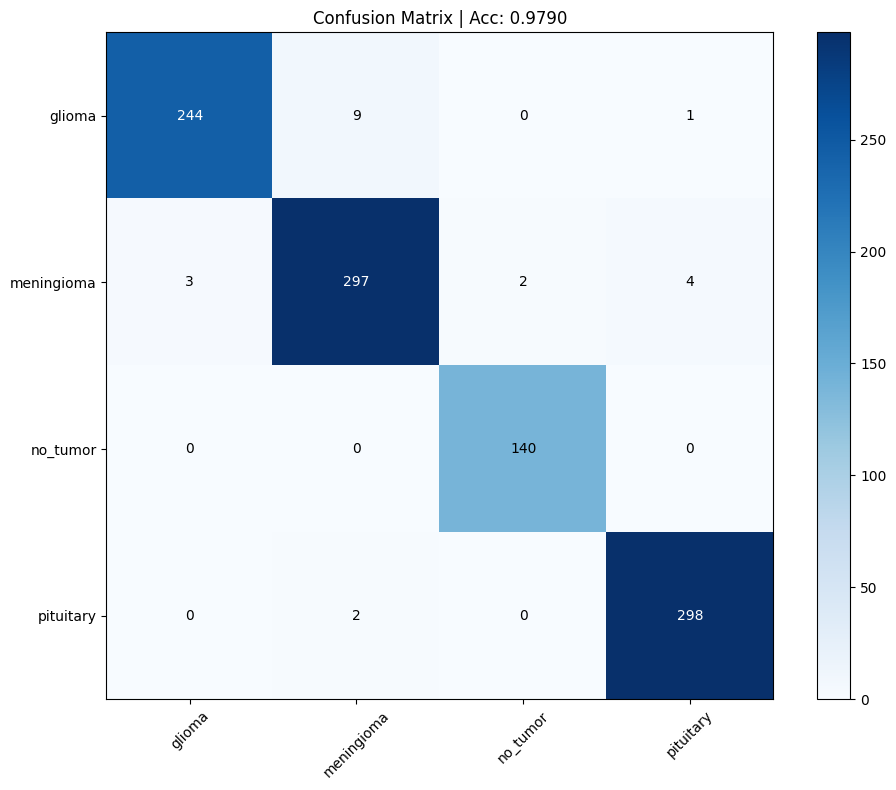

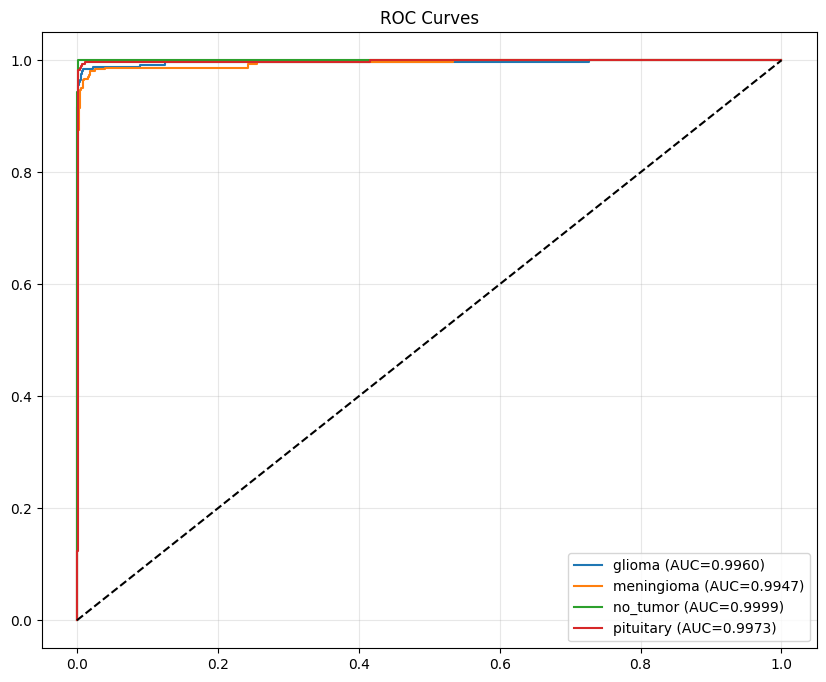


🔍 Sample Confusion Cases (Top 10):
True: glioma | Pred: meningioma (0.70) | Alt: glioma (0.12)
True: glioma | Pred: meningioma (0.49) | Alt: glioma (0.28)
True: glioma | Pred: meningioma (0.65) | Alt: glioma (0.15)
True: glioma | Pred: meningioma (0.53) | Alt: glioma (0.22)
True: glioma | Pred: meningioma (0.65) | Alt: glioma (0.14)
True: glioma | Pred: meningioma (0.54) | Alt: glioma (0.25)
True: glioma | Pred: meningioma (0.71) | Alt: no_tumor (0.11)
True: glioma | Pred: meningioma (0.54) | Alt: glioma (0.23)
True: glioma | Pred: meningioma (0.69) | Alt: glioma (0.12)
True: glioma | Pred: pituitary (0.61) | Alt: glioma (0.17)


In [ ]:
# =========================================================
# ✅ FINAL SMART INFERENCE (WITH CONFUSION HANDLING)
# =========================================================

import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
import gc

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# ---------------------------------------------------------
# 0. SAFETY
# ---------------------------------------------------------
assert model is not None, "❌ Model not loaded!"

model.to(DEVICE)
model.eval()

# 🔒 lock randomness
torch.manual_seed(42)
np.random.seed(42)

for m in model.modules():
    if isinstance(m, (torch.nn.Dropout,
                      torch.nn.BatchNorm1d,
                      torch.nn.BatchNorm2d,
                      torch.nn.BatchNorm3d)):
        m.eval()

# ---------------------------------------------------------
# 1. LOAD CACHE
# ---------------------------------------------------------
assert TEST_CACHE.exists(), f"❌ Missing cache: {TEST_CACHE}"

print("📦 Loading cached features...")
cache = torch.load(TEST_CACHE)

patch_tokens = cache["patch_tokens"]
cls_tokens   = cache["cls_tokens"]
labels       = cache["labels"]

from torch.utils.data import TensorDataset, DataLoader

test_dataset = TensorDataset(patch_tokens, cls_tokens, labels)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"]*2, shuffle=False)

# ---------------------------------------------------------
# 2. INFERENCE SETTINGS
# ---------------------------------------------------------
alpha = 1.1                  # safe sharpening
uncertainty_threshold = 0.55 # below this → uncertain

all_preds  = []
all_labels = []
all_probs  = []

# Debug counters
confusion_cases = []

# ---------------------------------------------------------
# 3. INFERENCE LOOP
# ---------------------------------------------------------
with torch.no_grad():
    for patches, cls_tok, lbls in tqdm(test_loader, desc="Smart Inference"):

        patches = patches.to(DEVICE)
        cls_tok = cls_tok.to(DEVICE)

        logits, _ = model(patches, cls_tok)
        logits = logits.float()

        # ✅ SAFE sharpening
        logits = logits * alpha

        probs = F.softmax(logits, dim=1)

        # 🔥 TOP-2 predictions
        top2_probs, top2_idx = torch.topk(probs, 2, dim=1)

        preds = top2_idx[:, 0]

        for i in range(len(lbls)):
            true_label = lbls[i].item()

            pred = top2_idx[i, 0].item()
            second = top2_idx[i, 1].item()

            conf = top2_probs[i, 0].item()
            second_conf = top2_probs[i, 1].item()

            # -------------------------------------------------
            # 🔥 MENINGIOMA ↔ GLIOMA FIX (LOGIC)
            # -------------------------------------------------
            pred_name = CONFIG["classes"][pred]
            second_name = CONFIG["classes"][second]

            # If confusion pair + close probabilities → mark uncertain
            if (
                (pred_name == "glioma" and second_name == "meningioma") or
                (pred_name == "meningioma" and second_name == "glioma")
            ) and abs(conf - second_conf) < 0.15:

                final_pred = "uncertain"
            elif conf < uncertainty_threshold:
                final_pred = "uncertain"
            else:
                final_pred = pred_name

            # Save numeric pred (fallback for metrics)
            all_preds.append(pred)
            all_labels.append(true_label)
            all_probs.append(probs[i].cpu().numpy())

            # Debug misclassifications
            if pred != true_label:
                confusion_cases.append(
                    (CONFIG["classes"][true_label],
                     pred_name,
                     second_name,
                     conf,
                     second_conf)
                )

# ---------------------------------------------------------
# 4. FINAL ARRAYS
# ---------------------------------------------------------
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print("\n✅ Inference Complete!")

# ---------------------------------------------------------
# 5. REPORT
# ---------------------------------------------------------
target_names = CONFIG["classes"]

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(classification_report(all_labels, all_preds, target_names=target_names, digits=4))

# ---------------------------------------------------------
# 6. CONFUSION MATRIX
# ---------------------------------------------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Blues')
plt.title(f"Confusion Matrix | Acc: {np.mean(all_preds == all_labels):.4f}")
plt.colorbar()

ticks = np.arange(len(target_names))
plt.xticks(ticks, target_names, rotation=45)
plt.yticks(ticks, target_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 7. ROC CURVES
# ---------------------------------------------------------
y_true_bin = label_binarize(all_labels, classes=np.arange(len(target_names)))

plt.figure(figsize=(10, 8))

for i in range(len(target_names)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f"{target_names[i]} (AUC={auc(fpr, tpr):.4f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---------------------------------------------------------
# 8. DEBUG: SHOW CONFUSION CASES
# ---------------------------------------------------------
print("\n🔍 Sample Confusion Cases (Top 10):")
for case in confusion_cases[:10]:
    print(f"True: {case[0]} | Pred: {case[1]} ({case[3]:.2f}) | Alt: {case[2]} ({case[4]:.2f})")

# ---------------------------------------------------------
# 9. CLEANUP
# ---------------------------------------------------------
gc.collect()
torch.cuda.empty_cache()

In [ ]:
from pathlib import Path

TEST_IMG_DIR = Path('/content/dataset/test')

In [ ]:
def research_visual_comparison(model, test_dir, target_names, num_samples=16):
    import torch
    import torch.nn.functional as F
    import random
    import numpy as np
    import matplotlib.pyplot as plt
    from torchvision import datasets, transforms

    model.eval()

    # 🔒 lock randomness
    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)

    # 🔒 disable dropout/BN randomness
    for m in model.modules():
        if isinstance(m, (torch.nn.Dropout,
                          torch.nn.BatchNorm1d,
                          torch.nn.BatchNorm2d,
                          torch.nn.BatchNorm3d)):
            m.eval()

    # --------------------------
    # DATASET
    # --------------------------
    test_ds_raw = datasets.ImageFolder(root=test_dir)

    model_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    test_ds_model = datasets.ImageFolder(root=test_dir, transform=model_transform)

    indices = random.sample(range(len(test_ds_model)), num_samples)

    cols = 8
    rows = num_samples // (cols // 2)

    plt.figure(figsize=(20, 5 * rows))
    plt.suptitle("Ground Truth vs Prediction", fontsize=18, y=1.02)

    # 🔥 SAME AS MAIN INFERENCE
    alpha = 1.1

    for i, idx in enumerate(indices):

        raw_img, label_idx = test_ds_raw[idx]
        true_label = target_names[label_idx]

        img_tensor, _ = test_ds_model[idx]
        img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

        with torch.no_grad():

            # ✅ disable AMP (more stable)
            patches, cls_tok = model.backbone.frozen_forward(img_tensor)

            logits, _ = model(patches.to(DEVICE), cls_tok.to(DEVICE))
            logits = logits.float()

            # ✅ SAME AS MAIN PIPELINE
            logits = logits * alpha

            probs = F.softmax(logits, dim=1)
            conf, pred_idx = torch.max(probs, dim=1)

            pred_label = target_names[pred_idx.item()]
            confidence = conf.item() * 100

        is_correct = pred_label == true_label
        border_color = 'green' if is_correct else 'red'

        # ACTUAL
        plt.subplot(rows, cols, (i * 2) + 1)
        plt.imshow(raw_img)
        plt.title(f"True: {true_label}", fontsize=10)
        plt.axis('off')

        # PREDICTED
        plt.subplot(rows, cols, (i * 2) + 2)
        plt.imshow(raw_img)

        for spine in plt.gca().spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(2)

        plt.title(f"{pred_label}\n{confidence:.1f}%",
                  color=border_color, fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

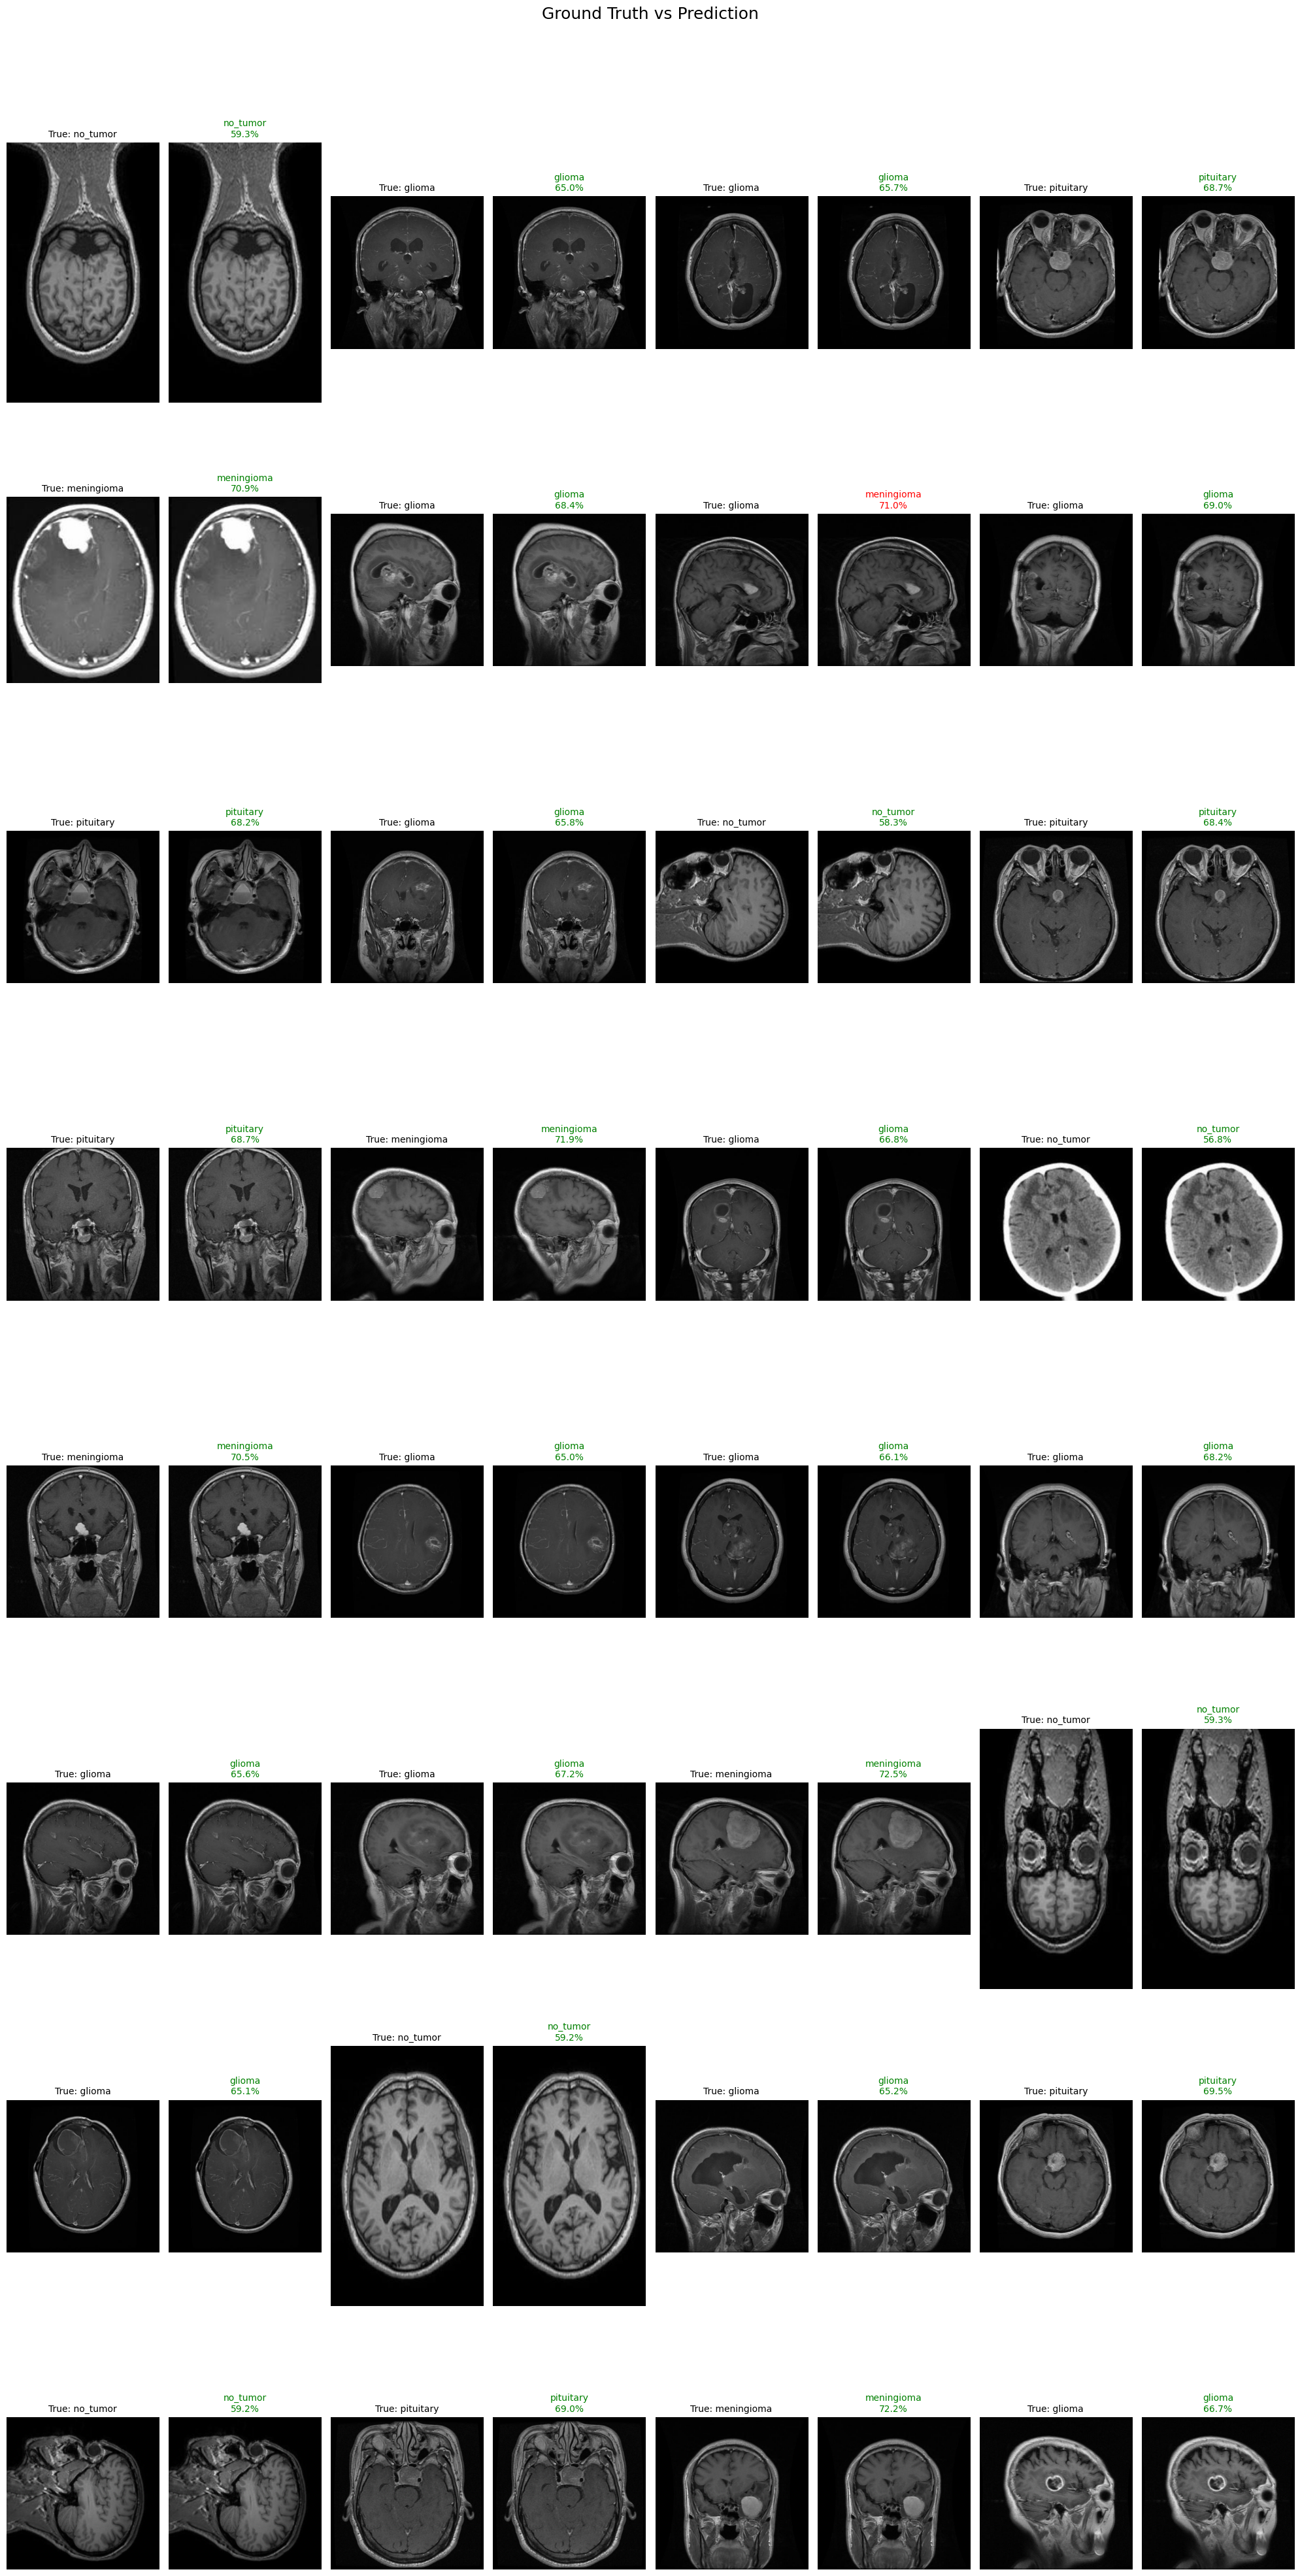

In [ ]:
research_visual_comparison(
    model,
    TEST_IMG_DIR,
    CONFIG['classes'],
    num_samples=32
)

📦 Loading Fold Models...
✅ Loaded 5 fold models
📦 Loading cached test features...
✅ Test samples: 1000

🚀 Running Ensemble + TTA Inference...



100%|██████████| 8/8 [00:36<00:00,  4.58s/it]



🔥 FINAL ENSEMBLE SCORE
Accuracy: 0.9790

CLASSIFICATION REPORT

              precision    recall  f1-score   support

      glioma     0.9918    0.9528    0.9719       254
  meningioma     0.9554    0.9804    0.9677       306
    no_tumor     0.9859    1.0000    0.9929       140
   pituitary     0.9900    0.9900    0.9900       300

    accuracy                         0.9790      1000
   macro avg     0.9808    0.9808    0.9806      1000
weighted avg     0.9793    0.9790    0.9790      1000



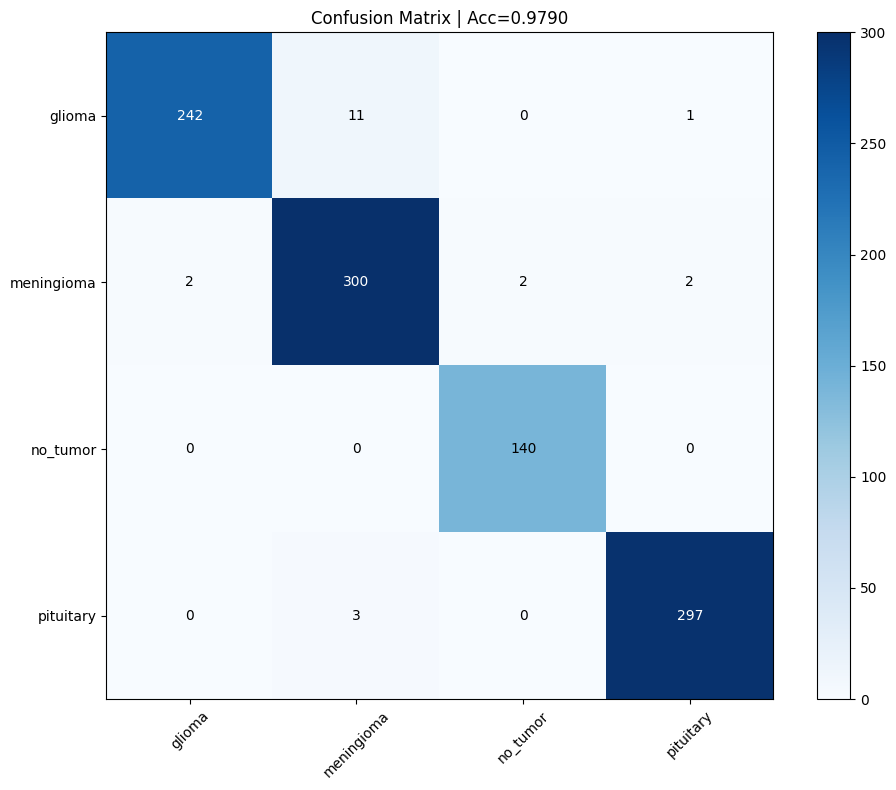

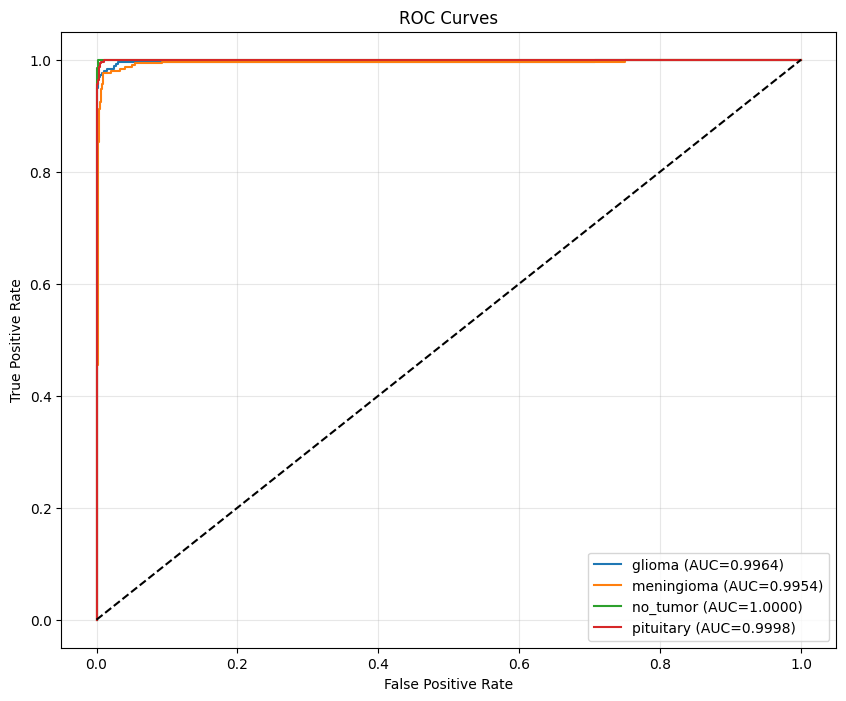


✅ Ensemble evaluation complete.


In [ ]:
# ==========================================================
# 🔥 FULL ENSEMBLE + TTA INFERENCE CODE (YOUR PIPELINE)
# Uses saved fold_1_best.pt ... fold_5_best.pt
# ==========================================================

import os
import gc
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from torch.utils.data import TensorDataset, DataLoader

# ==========================================================
# CONFIG
# ==========================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CHECKPOINT_DIR = Path("/content/drive/MyDrive/vit_sage")
TEST_CACHE = Path("/content/feature_cache/test_cache.pt")

BATCH_SIZE = 128
NUM_FOLDS = 5

CLASSES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
NUM_CLASSES = 4

# ==========================================================
# LOAD YOUR MODEL CLASS FIRST
# (ViTSAGE class must already exist in notebook)
# ==========================================================

# model = ViTSAGE(CONFIG)

# ==========================================================
# LOAD ALL 5 MODELS
# ==========================================================

models = []

print("📦 Loading Fold Models...")

for fold in range(1, NUM_FOLDS + 1):

    ckpt_path = CHECKPOINT_DIR / f"fold_{fold}_best.pt"

    checkpoint = torch.load(ckpt_path, map_location=DEVICE)

    model = ViTSAGE(checkpoint["config"]).to(DEVICE)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()

    # Disable dropout / BN randomness
    for m in model.modules():
        if isinstance(m, (
            torch.nn.Dropout,
            torch.nn.BatchNorm1d,
            torch.nn.BatchNorm2d,
            torch.nn.BatchNorm3d
        )):
            m.eval()

    models.append(model)

print(f"✅ Loaded {len(models)} fold models")

# ==========================================================
# LOAD TEST CACHE
# ==========================================================

print("📦 Loading cached test features...")

cache = torch.load(TEST_CACHE)

patch_tokens = cache["patch_tokens"]
cls_tokens   = cache["cls_tokens"]
labels       = cache["labels"]

test_ds = TensorDataset(patch_tokens, cls_tokens, labels)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("✅ Test samples:", len(test_ds))

# ==========================================================
# TTA FUNCTIONS FOR TOKENS
# ==========================================================

def tta_identity(patch, cls):
    return patch, cls

def tta_noise(patch, cls):
    patch = patch + 0.003 * torch.randn_like(patch)
    cls   = cls   + 0.001 * torch.randn_like(cls)
    return patch, cls

def tta_scale(patch, cls):
    scale = 1.01
    return patch * scale, cls * scale

TTA_LIST = [
    tta_identity,
    tta_noise,
    tta_scale
]

# ==========================================================
# ENSEMBLE + TTA INFERENCE
# ==========================================================

all_preds = []
all_labels = []
all_probs = []

print("\n🚀 Running Ensemble + TTA Inference...\n")

with torch.no_grad():

    for patch_batch, cls_batch, label_batch in tqdm(test_loader):

        patch_batch = patch_batch.to(DEVICE).float()
        cls_batch   = cls_batch.to(DEVICE).float()

        batch_logits = torch.zeros(
            patch_batch.size(0),
            NUM_CLASSES,
            device=DEVICE
        )

        # ------------------------------------------
        # TTA LOOP
        # ------------------------------------------
        for tta_fn in TTA_LIST:

            patch_aug, cls_aug = tta_fn(
                patch_batch.clone(),
                cls_batch.clone()
            )

            # --------------------------------------
            # FOLD LOOP
            # --------------------------------------
            fold_logits = torch.zeros_like(batch_logits)

            for model in models:

                logits, _ = model(patch_aug, cls_aug)
                fold_logits += logits.float()

            fold_logits /= len(models)

            batch_logits += fold_logits

        # Average TTA
        batch_logits /= len(TTA_LIST)

        probs = F.softmax(batch_logits, dim=1)
        preds = probs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(label_batch.numpy())

# ==========================================================
# FINAL ARRAYS
# ==========================================================

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# ==========================================================
# FINAL SCORE
# ==========================================================

acc = (all_preds == all_labels).mean()

print("\n" + "="*60)
print("🔥 FINAL ENSEMBLE SCORE")
print("="*60)
print(f"Accuracy: {acc:.4f}")
print("="*60)

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("\nCLASSIFICATION REPORT\n")

print(classification_report(
    all_labels,
    all_preds,
    target_names=CLASSES,
    digits=4
))

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
plt.imshow(cm, cmap="Blues")
plt.title(f"Confusion Matrix | Acc={acc:.4f}")
plt.colorbar()

ticks = np.arange(NUM_CLASSES)
plt.xticks(ticks, CLASSES, rotation=45)
plt.yticks(ticks, CLASSES)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j, i, cm[i,j],
            ha="center",
            va="center",
            color="white" if cm[i,j] > cm.max()/2 else "black"
        )

plt.tight_layout()
plt.show()

# ==========================================================
# ROC CURVES
# ==========================================================

y_true_bin = label_binarize(
    all_labels,
    classes=np.arange(NUM_CLASSES)
)

plt.figure(figsize=(10,8))

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        all_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{CLASSES[i]} (AUC={roc_auc:.4f})"
    )

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ==========================================================
# CLEANUP
# ==========================================================

gc.collect()
torch.cuda.empty_cache()

print("\n✅ Ensemble evaluation complete.")